## Now Building The model

In [1]:
import pickle
pickle.load(open('cleaned_df.pkl','rb'))

,track_name,track_artist,lyrics,track_popularity,track_album_name,playlist_name,playlist_genre,danceability,energy,loudness,...,instrumentalness,liveness,valence,tempo,language,lyrics_clean,mood,tempo_cat,lyrics_length,mood_enc
0,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,Love & Loss,Hard Rock Workout,rock,0.216686,0.878856,0.781738,...,0.010258,0.342212,0.390092,0.560561,en,the trees are singing in the wind the sky blue...,Angry,fast,"[the, trees, are, singing, in, the, wind, the,...",0
1,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,Gold,"Back in the day - R&B, New Jack Swing, Swingbe...",r&b,0.844728,0.646747,0.681389,...,0.007461,0.486135,0.646128,0.427315,en,na yeah spyderman and freeze in full effect uh...,Happy,medium,"[na, yeah, spyderman, and, freeze, in, full, e...",2
2,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,CeeLo's Magic Moment,Christmas Soul,r&b,0.358053,0.367810,0.742542,...,0.000000,0.057812,0.391132,0.465533,en,i really cant stay baby its cold outside ive g...,Sad,medium,"[i, really, cant, stay, baby, its, cold, outsi...",3
3,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,KARD 2nd Digital Single ‘Dumb Litty’,K-Party Dance Mix,pop,0.746234,0.885982,0.881397,...,0.000000,0.130382,0.219400,0.530810,en,get up out of my business you dont keep me fro...,Angry,fast,"[get, up, out, of, my, business, you, dont, ke...",0
4,Soldier,James TW,"Hold your breath, don't look down, keep trying...",70,Chapters,urban contemporary,r&b,0.440324,0.633513,0.730275,...,0.000000,0.089333,0.287052,0.632203,en,hold your breath dont look down keep trying da...,Angry,fast,"[hold, your, breath, dont, look, down, keep, t...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13686,Sick Feeling,boy pablo,"I had to catch the bus Alarm was shaking, oh A...",64,Soy Pablo,②⓪①⑨ mixed,rock,0.358053,0.496081,0.590695,...,0.000004,0.358429,0.389051,0.735355,en,i had to catch the bus alarm was shaking oh al...,Angry,fast,"[i, had, to, catch, the, bus, alarm, was, shak...",0
13687,Some Way,NAV,"Yeah, nah, nah, nah, nah, nah, nah, nah, nah N...",72,NAV,PROJECT: Contemporary,r&b,0.727694,0.710883,0.732235,...,0.000000,0.083658,0.323480,0.673329,en,yeah nah nah nah nah nah nah nah nah nah nah n...,Angry,fast,"[yeah, nah, nah, nah, nah, nah, nah, nah, nah,...",0
13688,Rising Like The Sun - Radio Mix,Qulinez,"Caught up in such a head rush, wide-eyed latel...",0,Rising Like The Sun,♥ EDM LOVE 2020,edm,0.420626,0.797414,0.744030,...,0.000000,0.330049,0.189217,0.519349,en,caught up in such a head rush wideeyed lately ...,Angry,medium,"[caught, up, in, such, a, head, rush, wideeyed...",0
13689,Bound,Ponderosa Twins Plus One,"Bound, bound Bound, bound Bound to fall in lov...",40,2+2+1 = (Digitally Remastered),Sexy Soul 2020,r&b,0.396292,0.532729,0.719387,...,0.000442,0.107070,0.653414,0.600515,en,bound bound bound bound bound to fall in love ...,Happy,fast,"[bound, bound, bound, bound, bound, to, fall, ...",2


In [2]:
df=pickle.load(open('cleaned_df.pkl','rb'))

In [3]:
df.head(1)

,track_name,track_artist,lyrics,track_popularity,track_album_name,playlist_name,playlist_genre,danceability,energy,loudness,...,instrumentalness,liveness,valence,tempo,language,lyrics_clean,mood,tempo_cat,lyrics_length,mood_enc
0,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,Love & Loss,Hard Rock Workout,rock,0.216686,0.878856,0.781738,...,0.010258,0.342212,0.390092,0.560561,en,the trees are singing in the wind the sky blue...,Angry,fast,"[the, trees, are, singing, in, the, wind, the,...",0


In [4]:
df.columns

Index(['track_name', 'track_artist', 'lyrics', 'track_popularity',
       'track_album_name', 'playlist_name', 'playlist_genre', 'danceability',
       'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'language', 'lyrics_clean', 'mood',
       'tempo_cat', 'lyrics_length', 'mood_enc'],
      dtype='str')

In [5]:
import pandas as pd
df=pd.DataFrame(df)

In [6]:
import numpy as np
audio_features=['danceability','loudness','acousticness','instrumentalness','liveness','tempo','speechiness','valence','energy']

In [7]:
X=df[audio_features].to_numpy(dtype=np.float64)

In [8]:
X.shape

(13691, 9)

In [9]:
print(f"Nan in X: {np.isnan(X).sum()}")

Nan in X: 0


In [10]:
y=df['mood_enc'].to_numpy(dtype=np.int32)

In [11]:
from sklearn.model_selection import train_test_split 

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)
# WE use stratify so that equal data go to each category 

In [13]:
X_train.shape

(10952, 9)

In [14]:
y_train.shape

(10952,)

## The Model is overfitting so will use cosine Similarity.. 

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [16]:
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
print(classification_report(y_test,y_pred))
print(knn.score(X_train,y_train))
print(knn.score(X_test,y_test))


              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1031
           1       0.78      0.70      0.74       152
           2       0.94      0.95      0.95      1234
           3       0.88      0.84      0.86       322

    accuracy                           0.92      2739
   macro avg       0.88      0.86      0.87      2739
weighted avg       0.92      0.92      0.92      2739

0.9532505478451424
0.918583424607521


In [17]:
from sklearn.ensemble import RandomForestClassifier
rff=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)
rff.fit(X_train,y_train)
y_pred1=rff.predict(X_test)
print(f"Training Accuracy",rff.score(X_train,y_train))
print(f"Training Accuracy",rff.score(X_test,y_test))
print(classification_report(y_test,y_pred))

Training Accuracy 1.0
Training Accuracy 1.0
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      1031
           1       0.78      0.70      0.74       152
           2       0.94      0.95      0.95      1234
           3       0.88      0.84      0.86       322

    accuracy                           0.92      2739
   macro avg       0.88      0.86      0.87      2739
weighted avg       0.92      0.92      0.92      2739



## Confusion Matrix

In [18]:
pickle.load(open('LabelEncoder.pkl','rb'))
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [19]:
y_pred_str=le.fit_transform(y_pred1)
y_pred_str=le.transform(y_test)


y_pred_str=le.inverse_transform(y_pred1)
y_test_str=le.inverse_transform(y_test)


In [20]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_str,y_pred_str,labels=le.classes_)


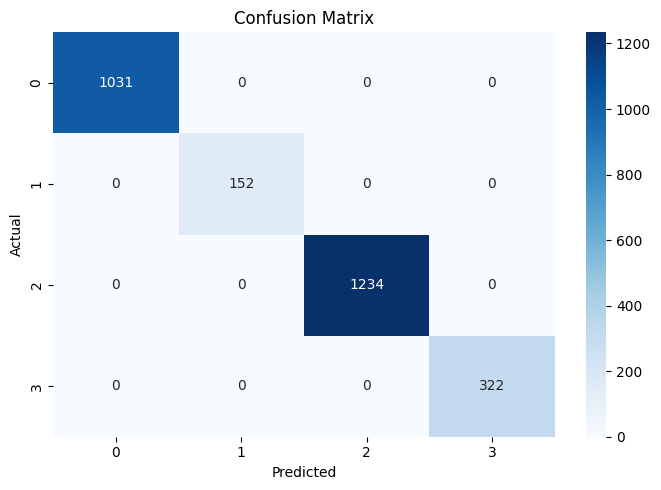

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=le.classes_,yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## It's time to now look at cleaned lyrics and apply tfidf Vectorizer

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=5000,stop_words='english')


In [23]:
tfidf_matrix=vectorizer.fit_transform(df['lyrics_clean'].tolist())


In [24]:
tfidf_matrix.shape

(13691, 5000)

In [25]:
## Search Tfidf
description=[
    f"{row['mood']} {row['tempo_cat']} {row['track_artist']}"
    for _,row in df.iterrows()
]
search_vectorizer=TfidfVectorizer(max_features=3000,stop_words='english')
search_matrix=search_vectorizer.fit_transform(description)

In [26]:
import pickle
pickle.dump(vectorizer,open('TfidfVectorizer.pkl','wb'))
pickle.dump(tfidf_matrix,open('Tfidf_matrix.pkl','wb'))
pickle.dump(search_matrix,open('search_matrix.pkl','wb'))
pickle.dump(search_vectorizer,open('search_vectorizer.pkl','wb'))


## Applying Cosine Similarity 

In [3]:
import pickle
df=pickle.load(open('cleaned_df.pkl','rb'))

In [4]:
from sklearn.metrics.pairwise import cosine_similarity


In [5]:
df.columns

Index(['track_name', 'track_artist', 'lyrics', 'track_popularity',
       'track_album_name', 'playlist_name', 'playlist_genre', 'danceability',
       'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'language', 'lyrics_clean', 'mood',
       'tempo_cat', 'lyrics_length', 'mood_enc'],
      dtype='str')

In [6]:
audio_features=['danceability','energy','valence','tempo','loudness','acousticness','instrumentalness','speechiness','liveness']

In [7]:
import numpy as np
import pandas as pd

In [8]:
def recommend_songs(song_name,top_n=5):
    song_name=str(song_name).strip()
    mask=df['track_name'].str.lower() == song_name.lower()
    if not mask.any():
        print(f'Song{song_name} not found!!')
        return
    song_idx = df[mask].index[0]
    song=df.loc[song_idx]

    ## Get Vectors
    song_vec=song[audio_features].to_numpy(dtype=np.float64).reshape(1,-1)
    all_vectors=df[audio_features].to_numpy(dtype=np.float64)

    ## Cosine Similarity
    similarity=cosine_similarity(song_vec,all_vectors)[0]
    top_idx=np.argsort(similarity)[-top_n-1:-1][::1]

    results=df.iloc[top_idx][
        ['track_name','track_artist','mood','tempo_cat']
    ].copy()
    results['similarity'] = similarity[top_idx].round(3)
    print(results.to_string(index=False))

    return results

In [12]:
recommend_songs("Someone Like You")

                                 track_name    track_artist mood tempo_cat  similarity
         What Are You Doing New Year's Eve?          Ledisi  Sad    medium       0.997
                                       Home         Fortuno  Sad    medium       0.997
Amsterdam - Recorded at Spotify Studios NYC Mandolin Orange  Sad      fast       0.997
                                  The Story      Conan Gray  Sad      fast       0.998
                                 These Days       Manwolves  Sad      fast       0.998


,track_name,track_artist,mood,tempo_cat,similarity
12849,What Are You Doing New Year's Eve?,Ledisi,Sad,medium,0.997
7408,Home,Fortuno,Sad,medium,0.997
8380,Amsterdam - Recorded at Spotify Studios NYC,Mandolin Orange,Sad,fast,0.997
2286,The Story,Conan Gray,Sad,fast,0.998
8818,These Days,Manwolves,Sad,fast,0.998


In [ ]:
df[df['track_name'].str.lower()=='shape of you']

,track_name,track_artist,lyrics,track_popularity,track_album_name,playlist_name,playlist_genre,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,language,lyrics_clean,mood,tempo_cat,lyrics_length,mood_enc
629,Shape of You,Ed Sheeran,The club isn't the best place to find a lover ...,75,Shape of You,Tropical House Run 190 BPM,latin,0.821553,0.646747,0.838209,0.064538,0.585685,0.00000,0.084874,0.938593,0.336316,en,the club isnt the best place to find a lover s...,Happy,medium,"[the, club, isnt, the, best, place, to, find, ...",2
10713,Shape of You,EZA,Oh—I—oh—I—oh—I—oh—I The club isn't the best pl...,2,Shape of You,Music&Other Drugs,pop,0.556199,0.380026,0.601401,0.226217,0.600806,0.00038,0.484108,0.648210,0.793530,en,ohiohiohiohi the club isnt the best place to f...,Calm,fast,"[ohiohiohiohi, the, club, isnt, the, best, pla...",1


In [11]:
print(df[df['track_name'] =='Believer']['mood'])

1264     Happy
12851    Happy
Name: mood, dtype: str
